In [1]:
import pandas as pd

# Part 1 - Data understanding, preparation and exploratory analysis

This section loads the 15-minute C&I electricity-load data, checks data types and quality, handles invalid readings and missing intervals, creates calendar and holiday features, and explores patterns relevant to BESS peak shaving.

In [2]:
df = pd.read_csv('load_timeseries_2025_case_study.csv', delimiter= ';')

In [3]:
df.dtypes

Timestamps    str
Load_kw       str
dtype: object

In [4]:
df.shape

(34901, 2)

In [5]:
df.head(10)

,Timestamps,Load_kw
0,01.01.2025 00:00,"2,38"
1,01.01.2025 00:15,"2,4"
2,01.01.2025 00:30,"5,12"
3,01.01.2025 00:45,"2,5"
4,01.01.2025 01:00,"2,42"
5,01.01.2025 01:15,"2,38"
6,01.01.2025 01:30,"2,38"
7,01.01.2025 01:45,"2,38"
8,01.01.2025 02:00,"2,4"
9,01.01.2025 02:15,"2,38"


In [6]:
df['Timestamps'] = pd.to_datetime(df['Timestamps'], format='%d.%m.%Y %H:%M')
df['Load_kw'] = pd.to_numeric(df['Load_kw'].str.replace(',', '.', regex=False))
df = df.rename(columns={
    'Timestamps': 'timestamp',
    'Load_kw': 'load'
})
df.dtypes

timestamp    datetime64[us]
load                float64
dtype: object

In [7]:
df.head(10)

,timestamp,load
0,2025-01-01 00:00:00,2.38
1,2025-01-01 00:15:00,2.40
2,2025-01-01 00:30:00,5.12
3,2025-01-01 00:45:00,2.50
4,2025-01-01 01:00:00,2.42
5,2025-01-01 01:15:00,2.38
6,2025-01-01 01:30:00,2.38
7,2025-01-01 01:45:00,2.38
8,2025-01-01 02:00:00,2.40
9,2025-01-01 02:15:00,2.38


In [8]:
df = df.set_index('timestamp')
df.index.duplicated().sum()

np.int64(0)

In [9]:
# Europe/Berlin switches from summer time on 26 October 2025
dst_day = df.loc['2025-10-26']
print(f'15-minute intervals on 2025-10-26: {len(dst_day)}')
dst_day.loc['2025-10-26 01:00':'2025-10-26 03:00']

15-minute intervals on 2025-10-26: 96


,load
timestamp,
2025-10-26 01:00:00,3.94
2025-10-26 01:15:00,4.10
2025-10-26 01:30:00,4.22
2025-10-26 01:45:00,4.30
2025-10-26 02:00:00,4.16
2025-10-26 02:15:00,4.18
2025-10-26 02:30:00,6.66
2025-10-26 02:45:00,4.28
2025-10-26 03:00:00,4.00


In [10]:
df['load'].isna().sum()

np.int64(18)

In [11]:
full_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='15min'
)
original_index = df.index.copy()
df = df.reindex(full_index)
df.index.name = 'timestamp'

In [12]:
df

,load
timestamp,
2025-01-01 00:00:00,2.38
2025-01-01 00:15:00,2.40
2025-01-01 00:30:00,5.12
2025-01-01 00:45:00,2.50
2025-01-01 01:00:00,2.42
...,...
2025-12-31 22:45:00,2.82
2025-12-31 23:00:00,2.82
2025-12-31 23:15:00,2.82


In [13]:
missing = pd.Series(~df.index.isin(original_index), index=df.index)
run_id = missing.ne(missing.shift()).cumsum()
missing_runs = (
    pd.DataFrame({'timestamp': df.index[missing], 'run_id': run_id[missing].to_numpy()})
    .groupby('run_id')
    .agg(start=('timestamp', 'min'), end=('timestamp', 'max'), intervals=('timestamp', 'size'))
)
single_intervals = (missing_runs['intervals'] == 1).sum()
contiguous_intervals = (missing_runs['intervals'] > 1).sum()
contiguous_missing_intervals = missing_runs.loc[missing_runs['intervals'] > 1, 'intervals'].sum()
print(f'Total missing intervals: {missing.sum()}')
print(f'Scattered single intervals: {single_intervals}')
print(f'Contiguous outage runs: {contiguous_intervals} ({contiguous_missing_intervals} intervals)')
missing_runs.sort_values('start')

Total missing intervals: 139
Scattered single intervals: 3
Contiguous outage runs: 5 (136 intervals)


,start,end,intervals
run_id,,,
2,2025-01-06 05:00:00,2025-01-06 05:00:00,1
4,2025-02-03 08:00:00,2025-02-03 09:45:00,8
6,2025-03-30 02:00:00,2025-03-30 02:45:00,4
8,2025-03-30 14:00:00,2025-03-30 14:00:00,1
10,2025-06-06 07:00:00,2025-06-06 07:45:00,4
12,2025-07-28 09:00:00,2025-07-28 14:45:00,24
14,2025-09-18 11:00:00,2025-09-18 11:00:00,1
16,2025-10-19 17:00:00,2025-10-20 16:45:00,96


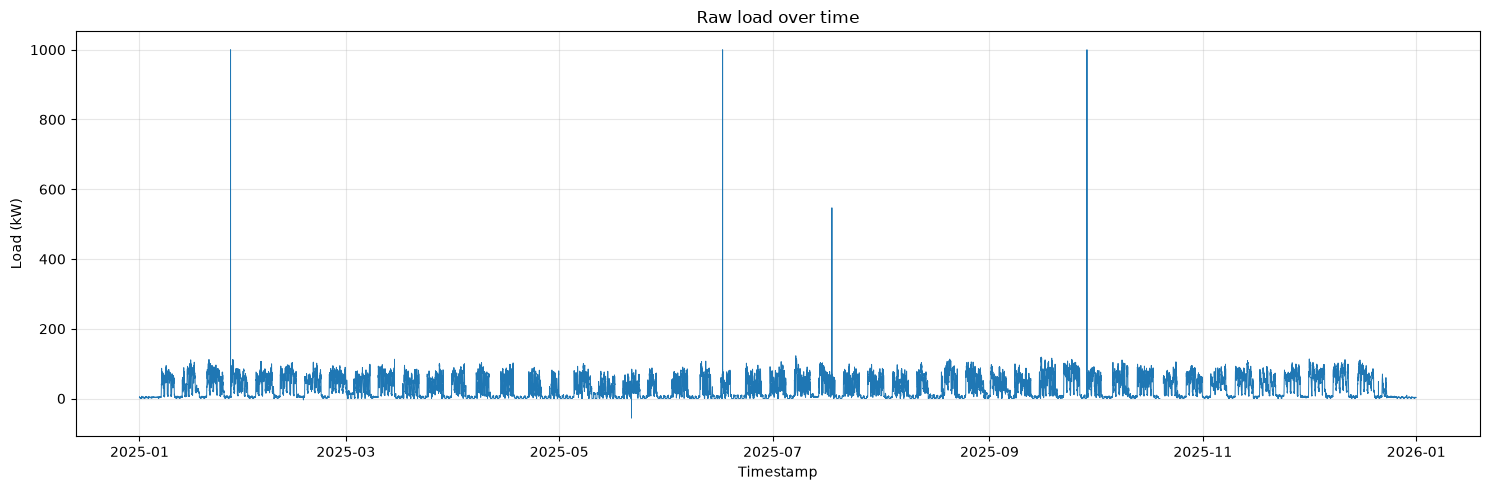

In [14]:
# Inspect raw readings before applying the high-value filter
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(df.index, df['load'], linewidth=0.7)
plt.xlabel('Timestamp')
plt.ylabel('Load (kW)')
plt.title('Raw load over time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
valid_load = df['load'].notna()
negative_values = valid_load & (df['load'] < 0)
zero_values = valid_load & (df['load'] == 0)
identical_pairs = valid_load & valid_load.shift(fill_value=False) & df['load'].eq(df['load'].shift())
nonzero_load = valid_load & df['load'].ne(0)
frozen_pairs = nonzero_load & nonzero_load.shift(fill_value=False) & df['load'].eq(df['load'].shift())

quality_summary = pd.Series({
    'negative load values': negative_values.sum(),
    'zero load values': zero_values.sum(),
    'identical consecutive pairs': identical_pairs.sum(),
    'identical consecutive nonzero pairs': frozen_pairs.sum()
})
quality_summary

negative load values                      2
zero load values                       3766
identical consecutive pairs            3769
identical consecutive nonzero pairs     281
dtype: int64

In [16]:
# Keep the raw load and create a cleaned modelling series
df['was_missing'] = df['load'].isna()
df['is_negative'] = df['load'] < 0
df['is_zero'] = df['load'] == 0
max_valid_load = 150
df['is_high'] = df['load'] > max_valid_load
# load_clean is an exploratory/visualization series; modelling uses a causal series below.
df['load_target'] = df['load'].mask(df['is_negative'] | df['is_high'])
df['load_clean'] = df['load_target'].interpolate(limit=4)

In [17]:
# Calendar features for modelling
df['minute'] = df.index.minute
df['hour'] = df.index.hour
df['day'] = df.index.day
df['month'] = df.index.month
df['weekday'] = df.index.dayofweek
df['weekday_name'] = df.index.day_name()
df['is_weekend'] = df.index.dayofweek >= 5

In [18]:
df

,load,was_missing,is_negative,is_zero,is_high,load_target,load_clean,minute,hour,day,month,weekday,weekday_name,is_weekend
timestamp,,,,,,,,,,,,,,
2025-01-01 00:00:00,2.38,False,False,False,False,2.38,2.38,0,0,1,1,2,Wednesday,False
2025-01-01 00:15:00,2.40,False,False,False,False,2.40,2.40,15,0,1,1,2,Wednesday,False
2025-01-01 00:30:00,5.12,False,False,False,False,5.12,5.12,30,0,1,1,2,Wednesday,False
2025-01-01 00:45:00,2.50,False,False,False,False,2.50,2.50,45,0,1,1,2,Wednesday,False
2025-01-01 01:00:00,2.42,False,False,False,False,2.42,2.42,0,1,1,1,2,Wednesday,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 22:45:00,2.82,False,False,False,False,2.82,2.82,45,22,31,12,2,Wednesday,False
2025-12-31 23:00:00,2.82,False,False,False,False,2.82,2.82,0,23,31,12,2,Wednesday,False
2025-12-31 23:15:00,2.82,False,False,False,False,2.82,2.82,15,23,31,12,2,Wednesday,False


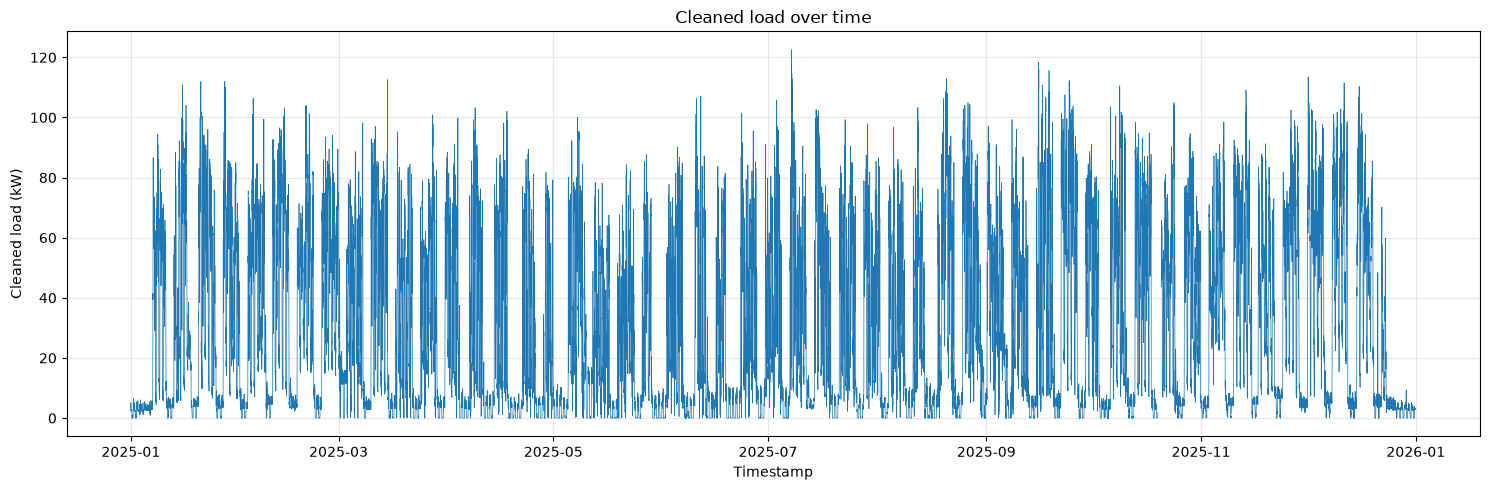

In [19]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['load_clean'], linewidth=0.5, color='tab:blue')
plt.xlabel('Timestamp')
plt.ylabel('Cleaned load (kW)')
plt.title('Cleaned load over time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

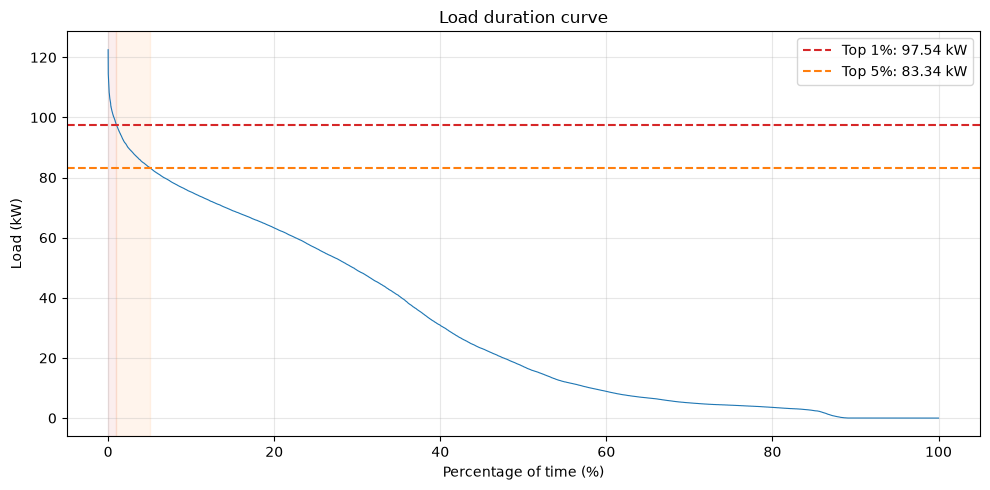

In [20]:
# Load duration curve
duration_values = df['load_clean'].dropna().sort_values(ascending=False).to_numpy()
duration_percent = (pd.Series(range(len(duration_values))) / len(duration_values) * 100).to_numpy()
duration_series = pd.Series(duration_values)
top_1_threshold = duration_series.quantile(0.99)
top_5_threshold = duration_series.quantile(0.95)

plt.figure(figsize=(10, 5))
plt.plot(duration_percent, duration_values, linewidth=0.8)
plt.axhline(top_1_threshold, color='tab:red', linestyle='--', label=f'Top 1%: {top_1_threshold:.2f} kW')
plt.axhline(top_5_threshold, color='tab:orange', linestyle='--', label=f'Top 5%: {top_5_threshold:.2f} kW')
plt.axvspan(0, 1, color='tab:red', alpha=0.08)
plt.axvspan(1, 5, color='tab:orange', alpha=0.08)
plt.xlabel('Percentage of time (%)')
plt.ylabel('Load (kW)')
plt.title('Load duration curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

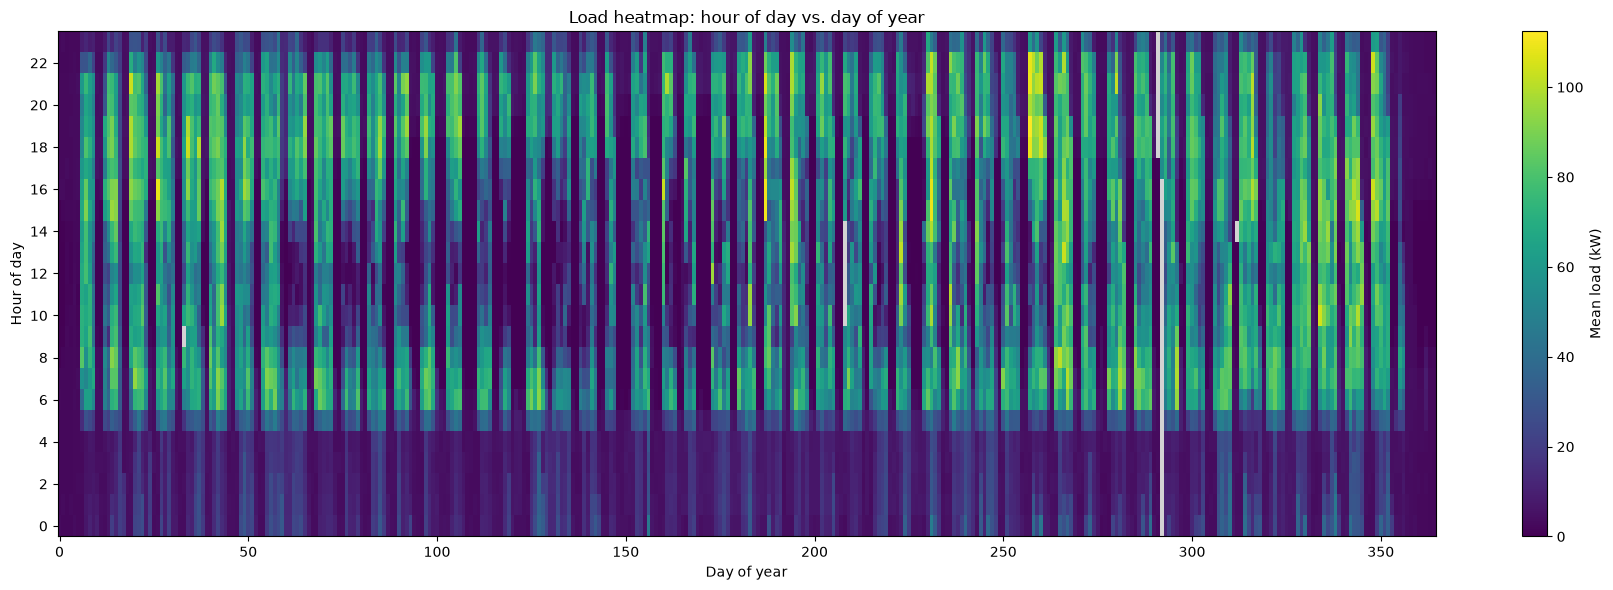

In [21]:
# Hour-of-day by day-of-year heatmap
heatmap_data = df[['load_clean']].copy()
heatmap_data['hour'] = heatmap_data.index.hour
heatmap_data['day_of_year'] = heatmap_data.index.dayofyear
heatmap = heatmap_data.pivot_table(
    index='hour', columns='day_of_year', values='load_clean', aggfunc='mean'
)

cmap = plt.cm.viridis.copy()
cmap.set_bad('lightgray')
plt.figure(figsize=(18, 6))
plt.imshow(heatmap, aspect='auto', origin='lower', interpolation='none', cmap=cmap)
plt.colorbar(label='Mean load (kW)')
plt.xlabel('Day of year')
plt.ylabel('Hour of day')
plt.title('Load heatmap: hour of day vs. day of year')
plt.yticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

In [22]:
import holidays

de = holidays.Germany(years=2025)   # nationwide only
df['is_holiday'] = df.index.normalize().isin(pd.to_datetime(list(de.keys())))
df['is_weekend'] = df.index.dayofweek >= 5

In [23]:
daily_max = df['load'].resample('D').max()
print(daily_max.loc['2025-12-15':'2025-12-31'])
print(daily_max.loc['2025-01-01':'2025-01-15'])

timestamp
2025-12-15    110.36
2025-12-16    101.30
2025-12-17     94.28
2025-12-18     73.44
2025-12-19     85.52
2025-12-20     23.56
2025-12-21     48.40
2025-12-22     70.16
2025-12-23     59.88
2025-12-24      7.12
2025-12-25      6.88
2025-12-26      5.96
2025-12-27      5.92
2025-12-28      5.30
2025-12-29      9.40
2025-12-30      5.18
2025-12-31      4.44
Freq: D, Name: load, dtype: float64
timestamp
2025-01-01      6.50
2025-01-02      5.78
2025-01-03      6.06
2025-01-04      5.54
2025-01-05      4.76
2025-01-06      5.86
2025-01-07     86.66
2025-01-08     94.46
2025-01-09     82.80
2025-01-10     71.04
2025-01-11     12.28
2025-01-12      6.76
2025-01-13     88.44
2025-01-14     92.22
2025-01-15    110.76
Freq: D, Name: load, dtype: float64


In [24]:
df['is_shutdown'] = (df.index.month == 12) & (df.index.day >= 24) | \
                    (df.index.month == 1) & (df.index.day <= 6)

In [25]:
df

,load,was_missing,is_negative,is_zero,is_high,load_target,load_clean,minute,hour,day,month,weekday,weekday_name,is_weekend,is_holiday,is_shutdown
timestamp,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,2.38,False,False,False,False,2.38,2.38,0,0,1,1,2,Wednesday,False,True,True
2025-01-01 00:15:00,2.40,False,False,False,False,2.40,2.40,15,0,1,1,2,Wednesday,False,True,True
2025-01-01 00:30:00,5.12,False,False,False,False,5.12,5.12,30,0,1,1,2,Wednesday,False,True,True
2025-01-01 00:45:00,2.50,False,False,False,False,2.50,2.50,45,0,1,1,2,Wednesday,False,True,True
2025-01-01 01:00:00,2.42,False,False,False,False,2.42,2.42,0,1,1,1,2,Wednesday,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 22:45:00,2.82,False,False,False,False,2.82,2.82,45,22,31,12,2,Wednesday,False,False,True
2025-12-31 23:00:00,2.82,False,False,False,False,2.82,2.82,0,23,31,12,2,Wednesday,False,False,True
2025-12-31 23:15:00,2.82,False,False,False,False,2.82,2.82,15,23,31,12,2,Wednesday,False,False,True


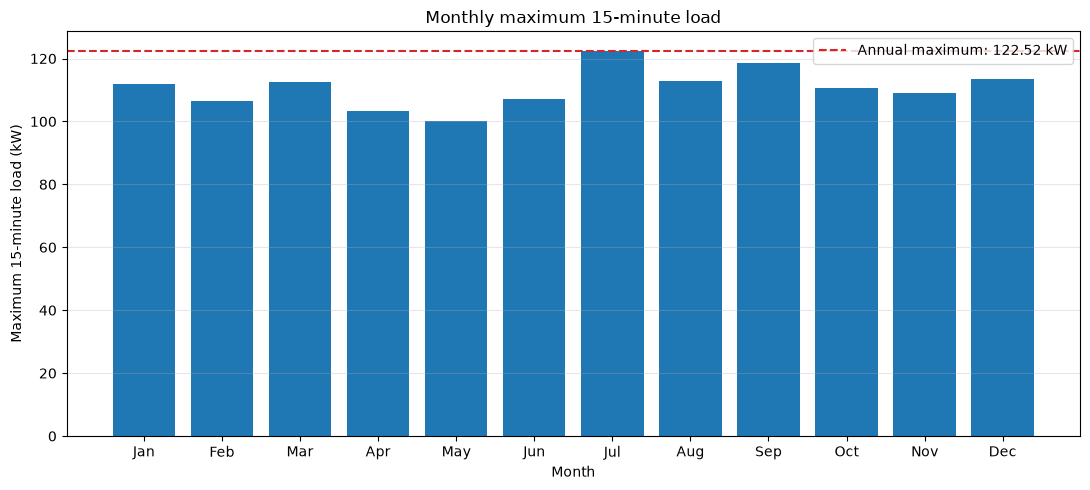

In [26]:
# Monthly maximum 15-minute load
monthly_max = df['load_clean'].resample('ME').max()
annual_max = df['load_clean'].max()

plt.figure(figsize=(11, 5))
plt.bar(monthly_max.index.strftime('%b'), monthly_max.values)
plt.axhline(annual_max, color='tab:red', linestyle='--', label=f'Annual maximum: {annual_max:.2f} kW')
plt.xlabel('Month')
plt.ylabel('Maximum 15-minute load (kW)')
plt.title('Monthly maximum 15-minute load')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

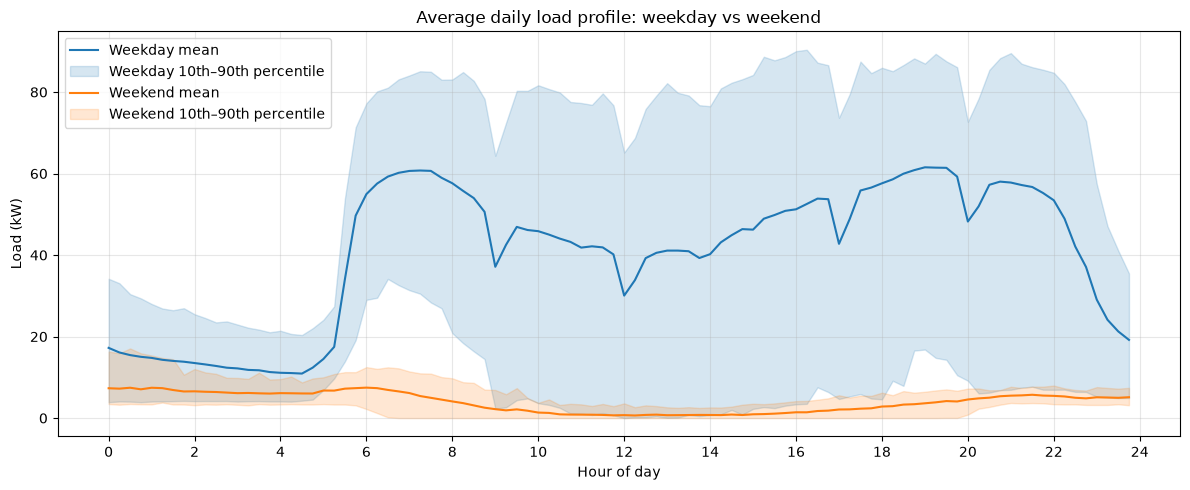

In [27]:
# Average daily profile: weekday vs weekend
profile = df[['load_clean']].copy()
profile['date'] = profile.index.normalize()
profile['time'] = profile.index.hour + profile.index.minute / 60
profile['day_type'] = profile.index.dayofweek.map(lambda day: 'Weekend' if day >= 5 else 'Weekday')
daily_profiles = profile.groupby(['day_type', 'date', 'time'])['load_clean'].mean().reset_index()

plt.figure(figsize=(12, 5))
for day_type, color in [('Weekday', 'tab:blue'), ('Weekend', 'tab:orange')]:
    values = daily_profiles[daily_profiles['day_type'] == day_type].pivot(index='date', columns='time', values='load_clean')
    mean = values.mean(axis=0)
    lower = values.quantile(0.10, axis=0)
    upper = values.quantile(0.90, axis=0)
    plt.plot(mean.index, mean.values, color=color, label=f'{day_type} mean')
    plt.fill_between(mean.index, lower.values, upper.values, color=color, alpha=0.18, label=f'{day_type} 10th–90th percentile')
plt.xlabel('Hour of day')
plt.ylabel('Load (kW)')
plt.title('Average daily load profile: weekday vs weekend')
plt.xticks(range(0, 25, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

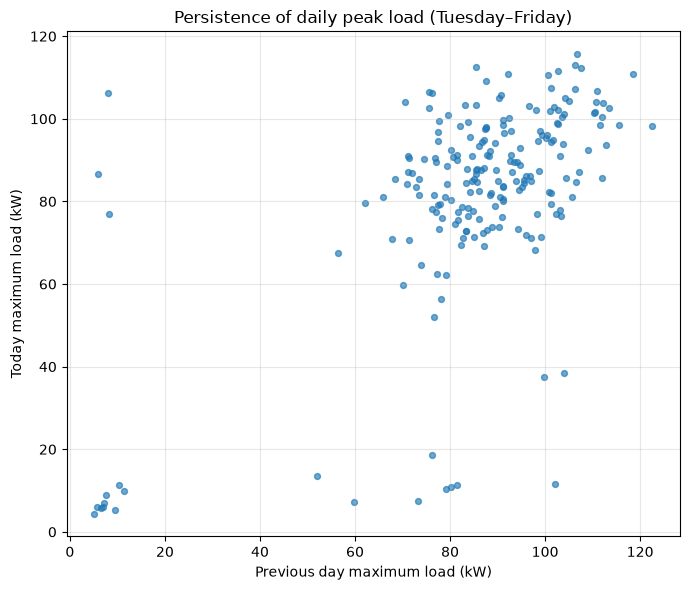

In [28]:
# Persistence of daily peak load
daily_peak = df['load_clean'].resample('D').max().dropna()
peak_persistence = pd.DataFrame({
    'today_max': daily_peak,
    'previous_day_max': daily_peak.shift(1)
}).dropna()
peak_persistence = peak_persistence[peak_persistence.index.dayofweek.isin([1, 2, 3, 4])]

plt.figure(figsize=(7, 6))
plt.scatter(peak_persistence['previous_day_max'], peak_persistence['today_max'], alpha=0.65, s=18)
plt.xlabel('Previous day maximum load (kW)')
plt.ylabel('Today maximum load (kW)')
plt.title('Persistence of daily peak load (Tuesday–Friday)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
df.head(100)

,load,was_missing,is_negative,is_zero,is_high,load_target,load_clean,minute,hour,day,month,weekday,weekday_name,is_weekend,is_holiday,is_shutdown
timestamp,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,2.38,False,False,False,False,2.38,2.38,0,0,1,1,2,Wednesday,False,True,True
2025-01-01 00:15:00,2.40,False,False,False,False,2.40,2.40,15,0,1,1,2,Wednesday,False,True,True
2025-01-01 00:30:00,5.12,False,False,False,False,5.12,5.12,30,0,1,1,2,Wednesday,False,True,True
2025-01-01 00:45:00,2.50,False,False,False,False,2.50,2.50,45,0,1,1,2,Wednesday,False,True,True
2025-01-01 01:00:00,2.42,False,False,False,False,2.42,2.42,0,1,1,1,2,Wednesday,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01 23:45:00,2.36,False,False,False,False,2.36,2.36,45,23,1,1,2,Wednesday,False,True,True
2025-01-02 00:00:00,2.36,False,False,False,False,2.36,2.36,0,0,2,1,3,Thursday,False,False,True
2025-01-02 00:15:00,2.40,False,False,False,False,2.40,2.40,15,0,2,1,3,Thursday,False,False,True


# Part 2 — Forecasting approach and validation

The forecasting objective is to support short-term BESS peak-shaving decisions. We use a day-ahead horizon: at the start of each day, the model forecasts the next 96 quarter-hour intervals. We compare a same-time-last-week lag-672 baseline with a LightGBM model using calendar, workday, comparable-day, lag, and rolling-load features. Models are evaluated with a rolling-origin expanding-window backtest, using MAE and RMSE overall and separately for weekdays and weekends.

In [30]:
# Forecasting features (15-minute data)
# Causal modelling series: use past values only; do not use two-sided interpolation.
df['load_model'] = df['load_target'].ffill(limit=4)
df['is_workday'] = ~(df['is_weekend'] | df['is_holiday'] | df['is_shutdown'])
# Same-time load from the most recent prior day with the same workday status.
daily_status = df['is_workday'].groupby(df.index.normalize()).first().astype(bool)
previous_same_status = {}
for current_date in daily_status.index:
    prior_dates = daily_status.index[(daily_status.index < current_date) & (daily_status == daily_status.loc[current_date])]
    previous_same_status[current_date] = prior_dates[-1] if len(prior_dates) else pd.NaT
reference_index = pd.DatetimeIndex([
    previous_same_status[timestamp.normalize()] + (timestamp - timestamp.normalize())
    if pd.notna(previous_same_status[timestamp.normalize()]) else pd.NaT
    for timestamp in df.index
])
df['lag_same_workday'] = df['load_model'].reindex(reference_index).to_numpy()
df['lag672'] = df['load_model'].shift(672)
# Day-ahead causality: shift the seven-day window by one full day (96 quarter-hours).
df['rolling_mean_week'] = df['load_model'].shift(96).rolling(672, min_periods=672).mean()
df['rolling_max_week'] = df['load_model'].shift(96).rolling(672, min_periods=672).max()

categorical_features = [
    'minute', 'hour', 'month', 'weekday',
    'is_weekend', 'is_holiday', 'is_shutdown', 'is_workday'
]
for column in categorical_features:
    df[column] = df[column].astype('category')

feature_columns = [
    'minute', 'hour', 'month', 'weekday',
    'is_weekend', 'is_holiday', 'is_shutdown', 'is_workday',
    'lag_same_workday', 'lag672', 'rolling_mean_week', 'rolling_max_week'
]
df[feature_columns].dtypes

minute               category
hour                 category
month                category
weekday              category
is_weekend           category
is_holiday           category
is_shutdown          category
is_workday           category
lag_same_workday      float64
lag672                float64
rolling_mean_week     float64
rolling_max_week      float64
dtype: object

In [31]:
# Rolling-origin expanding-window validation: predict each day from all prior days.
# Use 100 trees so the notebook remains practical when refitting point and P95 models.
from sklearn.metrics import mean_absolute_error, mean_squared_error
import sys

try:
    from lightgbm import LGBMRegressor
    lightgbm_available = True
except ImportError as error:
    lightgbm_available = False
    print(f'LightGBM could not be imported in {sys.executable}: {error}')

model_data = df[feature_columns + ['load_target']].dropna().copy()
model_data['date'] = model_data.index.normalize()
predictions = []
min_train_days = 28

for date in sorted(model_data['date'].unique()):
    train = model_data[model_data['date'] < date]
    test = model_data[model_data['date'] == date]
    if len(train) == 0 or (date - train['date'].min()).days < min_train_days or test.empty:
        continue

    result = pd.DataFrame(index=test.index)
    result['actual'] = test['load_target']
    result['baseline_lag672'] = test['lag672']
    result['baseline_same_workday'] = test['lag_same_workday']
    result['day_type'] = 'Weekend' if date.dayofweek >= 5 else 'Weekday'
    result['is_workday'] = bool(test['is_workday'].iloc[0])
    peak_threshold = train['load_target'].quantile(0.95)
    result['is_peak'] = result['actual'] >= peak_threshold

    if lightgbm_available:
        model = LGBMRegressor(
            n_estimators=100, learning_rate=0.05, num_leaves=31,
            random_state=42, verbosity=-1
        )
        model.fit(train[feature_columns], train['load_target'], categorical_feature=categorical_features)
        result['lightgbm'] = model.predict(test[feature_columns])
        quantile_model = LGBMRegressor(
            objective='quantile', alpha=0.95, n_estimators=100,
            learning_rate=0.05, num_leaves=31, random_state=42, verbosity=-1
        )
        quantile_model.fit(train[feature_columns], train['load_target'], categorical_feature=categorical_features)
        result['lightgbm_p95'] = quantile_model.predict(test[feature_columns])
    predictions.append(result)



In [32]:
validation_predictions = pd.concat(predictions).dropna(subset=['baseline_lag672'])
prediction_columns = {
    'lag-672 baseline': 'baseline_lag672',
    'same-workday baseline': 'baseline_same_workday'
}
if lightgbm_available:
    prediction_columns['LightGBM'] = 'lightgbm'
    prediction_columns['LightGBM P95'] = 'lightgbm_p95'

metric_rows = []
for day_type, group in validation_predictions.groupby('day_type'):
    for scope, scoped_group in [('all intervals', group), ('top 5% peaks', group[group['is_peak']])]:
        for model_name, prediction_column in prediction_columns.items():
            scored_group = scoped_group.dropna(subset=[prediction_column])
            if scored_group.empty:
                continue
            actual = scored_group['actual']
            forecast = scored_group[prediction_column]
            underforecast = (actual - forecast).clip(lower=0)
            metric_rows.append({
                'day_type': day_type,
                'scope': scope,
                'model': model_name,
                'MAE': mean_absolute_error(actual, forecast),
                'RMSE': mean_squared_error(actual, forecast) ** 0.5,
                'underforecast_rate': (underforecast > 0).mean()
            })
for scope, scoped_group in [('all intervals', validation_predictions), ('top 5% peaks', validation_predictions[validation_predictions['is_peak']])]:
    for model_name, prediction_column in prediction_columns.items():
        scored_group = scoped_group.dropna(subset=[prediction_column])
        if scored_group.empty:
            continue
        actual = scored_group['actual']
        forecast = scored_group[prediction_column]
        underforecast = (actual - forecast).clip(lower=0)
        metric_rows.append({
            'day_type': 'Overall',
            'scope': scope,
            'model': model_name,
            'MAE': mean_absolute_error(actual, forecast),
            'RMSE': mean_squared_error(actual, forecast) ** 0.5,
            'underforecast_rate': (underforecast > 0).mean()
        })
# Daily-peak error on genuine working days, matching the peak-shaving use case.
workday = validation_predictions[validation_predictions['is_workday']]
if not workday.empty:
    for model_name, prediction_column in prediction_columns.items():
        daily = workday.groupby(workday.index.normalize())[['actual', prediction_column]].max().dropna()
        metric_rows.append({
            'day_type': 'Working days', 'scope': 'daily peak', 'model': model_name,
            'MAE': mean_absolute_error(daily['actual'], daily[prediction_column]),
            'RMSE': mean_squared_error(daily['actual'], daily[prediction_column]) ** 0.5,
            'underforecast_rate': (daily['actual'] > daily[prediction_column]).mean()
        })
metrics_by_day_type_and_peak = pd.DataFrame(metric_rows).set_index(['day_type', 'scope', 'model']).sort_index()
metrics_by_day_type_and_peak

MAE       RMSE  \
day_type     scope         model                                         
Overall      all intervals LightGBM               11.057362  16.731062   
                           LightGBM P80           13.618925  19.924175   
                           lag-672 baseline       15.142546  23.753295   
                           same-workday baseline  13.142499  21.374567   
             top 5% peaks  LightGBM               29.615160  33.706792   
                           LightGBM P80           17.865819  21.908090   
                           lag-672 baseline       31.873004  39.401907   
                           same-workday baseline  27.838088  37.787321   
Weekday      all intervals LightGBM               14.376102  19.511064   
                           LightGBM P80           17.511576  23.174048   
                           lag-672 baseline       20.061133  27.858819   
                           same-workday baseline  17.390673  25.051700   
             top 5% peaks  LightGBM               29.615160  33.706792   
                           LightGBM P80           17.865819  21.908090   
                           lag-672 baseline       31.873004  39.401907   
                           same-workday baseline  27.838088  37.787321   
Weekend      all intervals LightGBM                2.743539   5.246912   
                           LightGBM P80            3.867389   6.789481   
                           lag-672 baseline        2.820923   5.779127   
                           same-workday baseline   2.500336   5.404631   
Working days daily peak    LightGBM               20.334312  23.894161   
                           LightGBM P80           14.341639  18.474803   
                           lag-672 baseline       18.604155  26.569353   
                           same-workday baseline  14.043285  20.603459   

                                                  underforecast_rate  
day_type     scope         model                                      
Overall      all intervals LightGBM                         0.415161  
                           LightGBM P80                     0.230024  
                           lag-672 baseline                 0.447783  
                           same-workday baseline            0.445039  
             top 5% peaks  LightGBM                         0.994448  
                           LightGBM P80                     0.950031  
                           lag-672 baseline                 0.903763  
                           same-workday baseline            0.851943  
Weekday      all intervals LightGBM                         0.461550  
                           LightGBM P80                     0.257243  
                           lag-672 baseline                 0.481334  
                           same-workday baseline            0.480313  
             top 5% peaks  LightGBM                         0.994448  
                           LightGBM P80                     0.950031  
                           lag-672 baseline                 0.903763  
                           same-workday baseline            0.851943  
Weekend      all intervals LightGBM                         0.298953  
                           LightGBM P80                     0.161836  
                           lag-672 baseline                 0.363736  
                           same-workday baseline            0.356673  
Working days daily peak    LightGBM                         0.859903  
                           LightGBM P80                     0.690821  
                           lag-672 baseline                 0.473430  
                           same-workday baseline            0.502415

# Part 3 — Business interpretation and reflection

## Forecasting choice
The LightGBM point forecast is the main forecasting approach because it captures calendar effects, workday status, comparable-day load, recent history, and weekly patterns while remaining interpretable through feature importance. The lag-672 forecast is retained as a transparent benchmark. The P95 LightGBM forecast is used as a more conservative peak-risk variant.

## Peak-shaving implications
A forecast can inform the battery about when the site is likely to exceed a demand threshold. The point forecast supports normal scheduling, while the P95 forecast provides a more conservative signal when under-forecasting a peak is more costly. Dispatch decisions should also consider battery state of charge, power and energy limits, round-trip efficiency, and remaining operating hours.

## Limitations and next steps
The analysis uses only historical load and calendar information. A production system would benefit from weather, production schedules, occupancy, tariffs, demand-charge windows, holidays specific to the site, and battery state information. Forecasts should be updated intraday as new measurements arrive, and model selection should ultimately use a cost-weighted metric reflecting demand charges and market-price opportunity costs.

In [33]:
# Reproducible business summary for peak-shaving interpretation
annual_peak_threshold = df['load_target'].quantile(0.95)
business_summary = pd.Series({
    'annual maximum load (kW)': df['load_target'].max(),
    '95th percentile load threshold (kW)': annual_peak_threshold,
    'number of validation intervals': len(validation_predictions),
    'actual validation peak intervals': (validation_predictions['actual'] >= annual_peak_threshold).sum(),
})
if 'lightgbm' in validation_predictions.columns:
    business_summary['LightGBM under-forecast rate'] = (validation_predictions['actual'] > validation_predictions['lightgbm']).mean()
if 'lightgbm_p95' in validation_predictions.columns:
    business_summary['LightGBM P95 under-forecast rate'] = (validation_predictions['actual'] > validation_predictions['lightgbm_p95']).mean()
business_summary

annual maximum load (kW)                 122.520000
95th percentile load threshold (kW)       83.360000
number of validation intervals         28784.000000
actual validation peak intervals        1465.000000
LightGBM under-forecast rate               0.415161
LightGBM P80 under-forecast rate           0.230024
dtype: float64